In [1]:
import os
os.environ.setdefault("BCD_DATA_FOLDER", "/data/gaetane")  # adapte si besoin

import torch
import matplotlib.pyplot as plt
import numpy as np

from dataloader import HiUCD_Dataset 
from encoder import DinoV2Encoder
from encoder import ChangeDetectionModel
from encoder import FeatureTransformer

In [2]:
ds_train = HiUCD_Dataset(cropsize=256, type="train", everything=True)

image1, image2, changemap, changemap2, landcover1, landcover2 = ds_train[9]

print("image1:", image1.shape, image1.dtype, image1.min().item(), image1.max().item())
print("image2:", image2.shape, image2.dtype, image2.min().item(), image2.max().item())
print("changemap:", changemap.shape, changemap.dtype, torch.unique(changemap))
print("landcover1:", landcover1.shape, landcover1.dtype, torch.unique(landcover1))
print("landcover2:", landcover2.shape, landcover2.dtype, torch.unique(landcover2))

image1: torch.Size([3, 256, 256]) torch.float32 0.054901961237192154 0.7607843279838562
image2: torch.Size([3, 256, 256]) torch.float32 0.054901961237192154 0.9058823585510254
changemap: torch.Size([256, 256]) torch.int32 tensor([0], dtype=torch.int32)
landcover1: torch.Size([256, 256]) torch.int64 tensor([0, 2, 5])
landcover2: torch.Size([256, 256]) torch.int64 tensor([0, 2, 5])


In [3]:
diff_mask = (landcover1 != landcover2).int()
changemap_np = changemap.squeeze().numpy()
diff_np = diff_mask.squeeze().numpy() if diff_mask.dim() > 2 else diff_mask.numpy()

agreement = (changemap_np == diff_np).mean()
print(f"Accord changemap vs (landcover1 != landcover2): {agreement:.3f}")
print("Proportion de pixels 'changé' dans changemap:", changemap_np.mean())
print("Proportion de pixels avec landcover1 != landcover2:", diff_np.mean())

Accord changemap vs (landcover1 != landcover2): 1.000
Proportion de pixels 'changé' dans changemap: 0.0
Proportion de pixels avec landcover1 != landcover2: 0.0


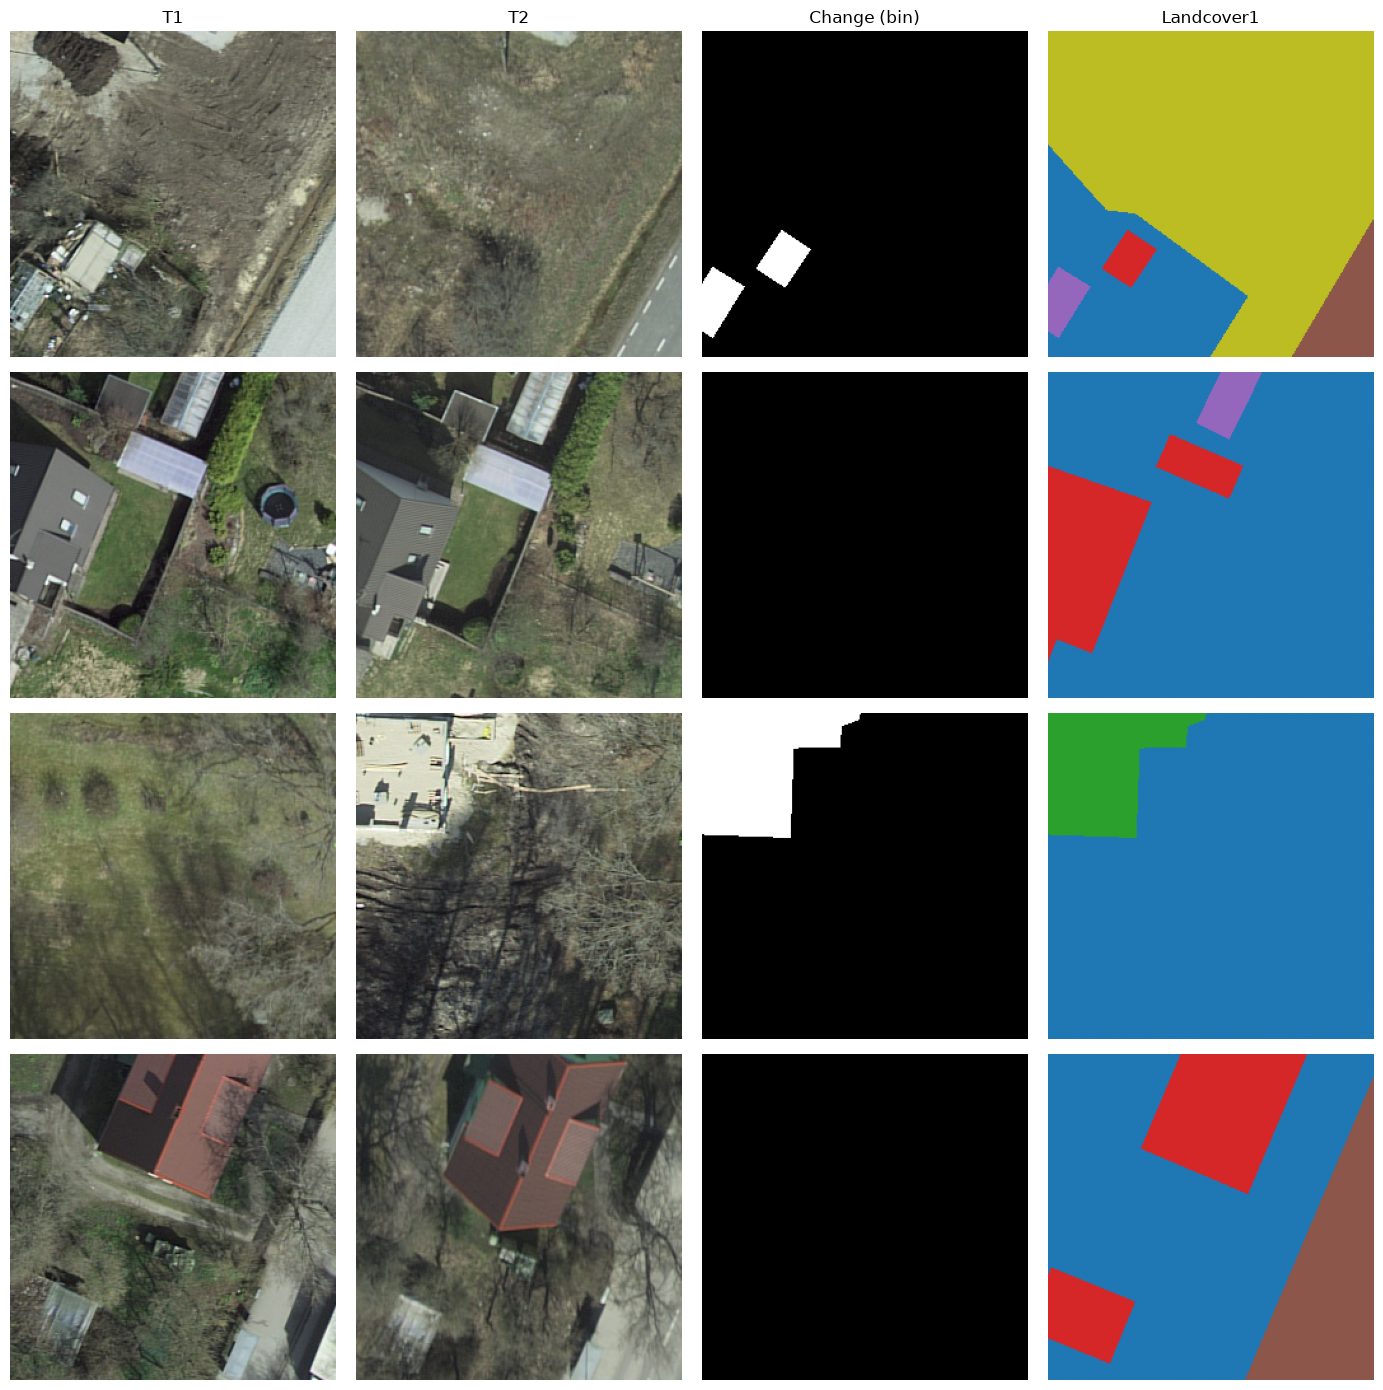

In [4]:
from torch.utils.data import DataLoader

loader = DataLoader(ds_train, batch_size=4, shuffle=True)
image1, image2, changemap, _, landcover1, landcover2 = next(iter(loader))

fig, axs = plt.subplots(4, 4, figsize=(14, 14))
titles = ["T1", "T2", "Change (bin)", "Landcover1"]
for i in range(4):
    axs[i, 0].imshow(image1[i].permute(1, 2, 0))
    axs[i, 1].imshow(image2[i].permute(1, 2, 0))
    axs[i, 2].imshow(changemap[i], cmap="gray", vmin=0, vmax=1)
    axs[i, 3].imshow(landcover1[i], cmap="tab10", vmin=0, vmax=9)
    for j in range(4):
        axs[i, j].axis("off")
        if i == 0:
            axs[i, j].set_title(titles[j])
plt.tight_layout()
plt.show()


## Vérification encodeur 


In [5]:
encoder = DinoV2Encoder(model_name="dinov2_vits14", freeze=True, resize_to=224)

im1, im2, changemap, _, landcover1, landcover2 = ds_train[0]
im1_batch = im1.unsqueeze(0)

with torch.no_grad():
    x = encoder(im1_batch)

print("x shape:", x.shape)
print("out_channels attendu:", encoder.out_channels)

Using cache found in /home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main
/home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


x shape: torch.Size([1, 384, 16, 16])
out_channels attendu: 384


In [6]:
encoder = DinoV2Encoder(model_name="dinov2_vits14", freeze=True, resize_to=224)
transformer = FeatureTransformer(embed_dim=encoder.out_channels, n_heads=6)
model = ChangeDetectionModel(encoder, transformer)

im1, im2, changemap, _, landcover1, landcover2 = ds_train[0]
im1_batch, im2_batch = im1.unsqueeze(0), im2.unsqueeze(0)

x_hat, y = model(im1_batch, im2_batch)
print("x_hat:", x_hat.shape)
print("y:", y.shape)

Using cache found in /home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main


x_hat: torch.Size([1, 384, 16, 16])
y: torch.Size([1, 384, 16, 16])


In [7]:
print(ds_train.cropsize)

256


check forward

In [10]:
encoder = DinoV2Encoder(model_name="dinov2_vits14", freeze=True, resize_to=224)
transformer = FeatureTransformer(embed_dim=encoder.out_channels, n_heads=6)
model = ChangeDetectionModel(encoder, transformer)

im1, im2, changemap, _, landcover1, landcover2 = ds_train[0]
im1_batch, im2_batch = im1.unsqueeze(0), im2.unsqueeze(0)

x_hat, y = model(im1_batch, im2_batch)
print("x_hat:", x_hat.shape, x_hat.requires_grad)
print("y:", y.shape, y.requires_grad)

Using cache found in /home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main


x_hat: torch.Size([1, 384, 16, 16]) True
y: torch.Size([1, 384, 16, 16]) False


In [11]:
with torch.no_grad():
    x_hat, y = model(im1_fixed, im2_fixed)
    print("std par token, cible y :", y.permute(0,2,3,1).reshape(-1, 384).std(dim=1).mean().item())
    print("std par token, x_hat   :", x_hat.permute(0,2,3,1).reshape(-1, 384).std(dim=1).mean().item())

std par token, cible y : 2.3228588104248047
std par token, x_hat   : 1.0013008117675781


backward une fois 

In [9]:
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.transformer.parameters(), lr=1e-4)

params_before = [p.clone().detach() for p in model.transformer.parameters()]

optimizer.zero_grad()
x_hat, y = model(im1_batch, im2_batch)
loss = loss_fn(x_hat, y)
loss.backward()
optimizer.step()

params_after = [p.clone().detach() for p in model.transformer.parameters()]

changed = [not torch.equal(a, b) for a, b in zip(params_before, params_after)]
print("Loss initiale:", loss.item())
print("Tous les paramètres ont changé:", all(changed))
print("Nombre de paramètres inchangés:", changed.count(False))

Loss initiale: 5.521401882171631
Tous les paramètres ont changé: True
Nombre de paramètres inchangés: 0


overfit sur un batch

Using cache found in /home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main


pos_embed dans l'optimizer : True
[identity] baseline = 3.8821 | std par token de la cible = 2.361
step    0 | loss 5.818254 | loss/baseline 1.4988 | grad norm 6.1587
step   50 | loss 1.993859 | loss/baseline 0.5136 | grad norm 1.4951
step  100 | loss 1.827641 | loss/baseline 0.4708 | grad norm 0.6177
step  150 | loss 1.743705 | loss/baseline 0.4492 | grad norm 0.9119
step  200 | loss 1.672489 | loss/baseline 0.4308 | grad norm 0.3505
step  250 | loss 1.621838 | loss/baseline 0.4178 | grad norm 1.3473
step  300 | loss 1.560031 | loss/baseline 0.4019 | grad norm 0.8962
step  350 | loss 1.502234 | loss/baseline 0.3870 | grad norm 0.3813
step  400 | loss 1.450947 | loss/baseline 0.3738 | grad norm 0.2971
step  450 | loss 1.402733 | loss/baseline 0.3613 | grad norm 0.4643
step  500 | loss 1.355807 | loss/baseline 0.3492 | grad norm 0.4613
step  550 | loss 1.309800 | loss/baseline 0.3374 | grad norm 0.3047
step  600 | loss 1.267777 | loss/baseline 0.3266 | grad norm 0.5557
step  650 | loss 

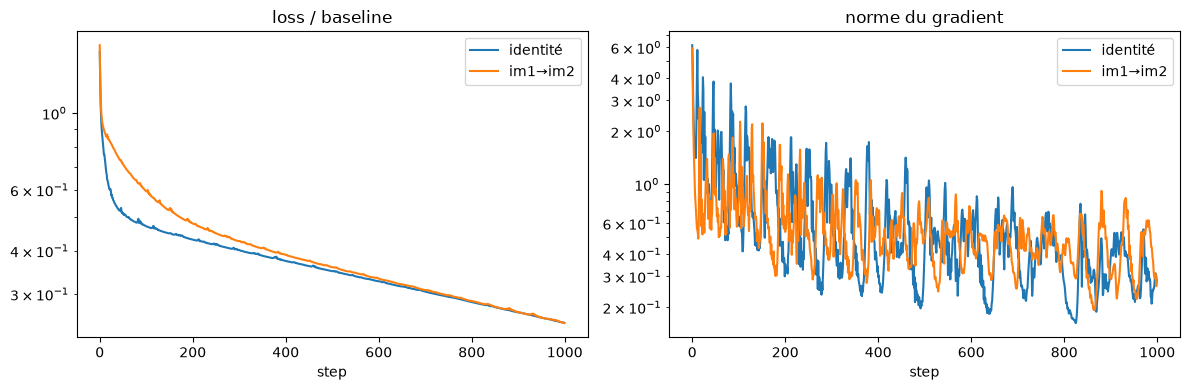

In [13]:
import os
os.environ.setdefault("BCD_DATA_FOLDER", "/data/gaetane")

import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from dataloader import HiUCD_Dataset
from encoder import DinoV2Encoder, FeatureTransformer, ChangeDetectionModel

ds_train = HiUCD_Dataset(cropsize=256, type="train", everything=True)

# batch fixe de 4 images, le même pour tous les tests
torch.manual_seed(0)
loader = DataLoader(ds_train, batch_size=4, shuffle=True)
im1_fixed, im2_fixed, *_ = next(iter(loader))

# encodeur créé une seule fois (gelé, pas besoin de le recréer)
encoder = DinoV2Encoder(model_name="dinov2_vits14", freeze=True, resize_to=224)


def overfit(target_mode="identity", steps=1000, lr=3e-4):
    torch.manual_seed(0)
    transformer = FeatureTransformer(embed_dim=encoder.out_channels, n_heads=6, dropout=0.0)
    model = ChangeDetectionModel(encoder, transformer)
    model.transformer.train()

    params = list(model.transformer.parameters())
    optimizer = torch.optim.Adam(params, lr=lr)
    loss_fn = torch.nn.MSELoss()

    # vérif : pos_embed est bien dans l'optimizer
    opt_ids = {id(p) for g in optimizer.param_groups for p in g["params"]}
    print("pos_embed dans l'optimizer :", id(transformer.pos_embed) in opt_ids)

    # cible fixe et baseline
    with torch.no_grad():
        x_in = encoder(im1_fixed)
        y = x_in.clone() if target_mode == "identity" else encoder(im2_fixed)
        baseline = ((y - y.mean(dim=(0, 2, 3), keepdim=True)) ** 2).mean().item()
        y_std = y.permute(0, 2, 3, 1).reshape(-1, y.shape[1]).std(dim=1).mean().item()
    print(f"[{target_mode}] baseline = {baseline:.4f} | std par token de la cible = {y_std:.3f}")

    losses, gnorms = [], []
    for step in range(steps):
        optimizer.zero_grad()
        x_hat = model.transformer(x_in)
        loss = loss_fn(x_hat, y)
        loss.backward()
        gn = torch.nn.utils.clip_grad_norm_(params, float("inf")).item()
        optimizer.step()
        losses.append(loss.item())
        gnorms.append(gn)
        if step % 50 == 0 or step == steps - 1:
            print(f"step {step:4d} | loss {loss.item():.6f} | loss/baseline {loss.item()/baseline:.4f} | grad norm {gn:.4f}")

    with torch.no_grad():
        x_hat = model.transformer(x_in)
        x_std = x_hat.permute(0, 2, 3, 1).reshape(-1, x_hat.shape[1]).std(dim=1).mean().item()
    print(f"std par token de x_hat à la fin = {x_std:.3f} (cible : {y_std:.3f})\n")
    return losses, gnorms, baseline


# 1) identité : doit converger vers ~0
l_id, g_id, b_id = overfit("identity")

# 2) im1 -> im2
l_im2, g_im2, b_im2 = overfit("im2")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for l, g, b, name in [(l_id, g_id, b_id, "identité"), (l_im2, g_im2, b_im2, "im1→im2")]:
    ax[0].plot([v / b for v in l], label=name)
    ax[1].plot(g, label=name)
ax[0].set_yscale("log"); ax[0].set_title("loss / baseline"); ax[0].set_xlabel("step"); ax[0].legend()
ax[1].set_yscale("log"); ax[1].set_title("norme du gradient"); ax[1].set_xlabel("step"); ax[1].legend()
plt.tight_layout(); plt.show()

In [14]:
l_id, g_id, b_id = overfit("identity", steps=3000, lr=1e-3)

pos_embed dans l'optimizer : True
[identity] baseline = 3.8821 | std par token de la cible = 2.361
step    0 | loss 5.818254 | loss/baseline 1.4988 | grad norm 6.1587
step   50 | loss 3.688427 | loss/baseline 0.9501 | grad norm 0.4709
step  100 | loss 3.660394 | loss/baseline 0.9429 | grad norm 0.0611
step  150 | loss 3.628604 | loss/baseline 0.9347 | grad norm 0.0488
step  200 | loss 3.606167 | loss/baseline 0.9289 | grad norm 0.0389
step  250 | loss 3.590566 | loss/baseline 0.9249 | grad norm 0.0308
step  300 | loss 3.579738 | loss/baseline 0.9221 | grad norm 0.0245
step  350 | loss 3.572058 | loss/baseline 0.9201 | grad norm 0.0208
step  400 | loss 3.566384 | loss/baseline 0.9187 | grad norm 0.0163
step  450 | loss 3.561986 | loss/baseline 0.9175 | grad norm 0.0138
step  500 | loss 3.558437 | loss/baseline 0.9166 | grad norm 0.0120
step  550 | loss 3.555503 | loss/baseline 0.9159 | grad norm 0.0105
step  600 | loss 3.553059 | loss/baseline 0.9152 | grad norm 0.0093
step  650 | loss 

KeyboardInterrupt: 

In [11]:
from torch.utils.data import DataLoader

loader = DataLoader(ds_train, batch_size=4, shuffle=True)
im1_fixed, im2_fixed, cm_fixed, _, lc1_fixed, lc2_fixed = next(iter(loader))

model = ChangeDetectionModel(encoder, transformer)
optimizer = torch.optim.Adam(model.transformer.parameters(), lr=1e-2) #learning rate
loss_fn = torch.nn.MSELoss()

losses = []
for step in range(300):
    optimizer.zero_grad()
    x_hat, y = model(im1_fixed, im2_fixed)
    loss = loss_fn(x_hat, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if step % 10 == 0:
        print(f"step {step}: loss = {loss.item():.6f}")

step 0: loss = 5.405752
step 10: loss = 3.951928
step 20: loss = 3.891779
step 30: loss = 3.863449
step 40: loss = 3.860187
step 50: loss = 3.858597
step 60: loss = 3.848439
step 70: loss = 3.846306
step 80: loss = 3.839272
step 90: loss = 3.832161
step 100: loss = 3.830827
step 110: loss = 3.827022


KeyboardInterrupt: 

In [12]:
print(transformer.pos_embed.shape)
id_before = id(transformer.pos_embed)

for step in range(5):
    x_hat, y = model(im1_fixed, im2_fixed)
    loss = loss_fn(x_hat, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

id_after = id(transformer.pos_embed)
print("Même objet pos_embed:", id_before == id_after)

torch.Size([1, 256, 384])


Même objet pos_embed: True


In [ ]:
# vérification que le gradient curcule bien dans tout les blocs 
x_hat, y = model(im1_fixed, im2_fixed)
loss = loss_fn(x_hat, y)
loss.backward()

for name, p in transformer.named_parameters():
    grad_norm = p.grad.norm().item() if p.grad is not None else None #calcule magnitude du gradient pour un paramètre p 
    print(f"{name}: grad_norm={grad_norm}")

optimizer.zero_grad()

pos_embed: grad_norm=1.1551486329974825e-11
transformer_encoder.layers.0.self_attn.in_proj_weight: grad_norm=2.6218274773448513e-10
transformer_encoder.layers.0.self_attn.in_proj_bias: grad_norm=2.7453261018661745e-12
transformer_encoder.layers.0.self_attn.out_proj.weight: grad_norm=2.730256576377599e-10
transformer_encoder.layers.0.self_attn.out_proj.bias: grad_norm=4.1945299230489175e-13
transformer_encoder.layers.0.linear1.weight: grad_norm=1.152550971328381e-10
transformer_encoder.layers.0.linear1.bias: grad_norm=4.265310760837027e-12
transformer_encoder.layers.0.linear2.weight: grad_norm=2.0497982478051568e-10
transformer_encoder.layers.0.linear2.bias: grad_norm=8.100582921458099e-13
transformer_encoder.layers.0.norm1.weight: grad_norm=1.3418608238446872e-11
transformer_encoder.layers.0.norm1.bias: grad_norm=8.271869300635615e-12
transformer_encoder.layers.0.norm2.weight: grad_norm=1.4198449360680598e-10
transformer_encoder.layers.0.norm2.bias: grad_norm=1.4825358995995686e-10
tra

In [16]:
#test avec un transformer simple pour voir si ct un pb de profondeur
transformer_simple = FeatureTransformer(embed_dim=384, n_heads=6, n_encoder_layers=1, n_decoder_layers=1)
model_simple = ChangeDetectionModel(encoder, transformer_simple)
optimizer_simple = torch.optim.Adam(model_simple.transformer.parameters(), lr=1e-3)

for step in range(1000):
    optimizer_simple.zero_grad()
    x_hat, y = model_simple(im1_fixed, im2_fixed)
    loss = loss_fn(x_hat, y)
    loss.backward()
    optimizer_simple.step()
    if step % 10 == 0:
        print(f"step {step}: loss = {loss.item():.6f}")
    

step 0: loss = 4.204967
step 10: loss = 2.995122
step 20: loss = 2.772451
step 30: loss = 2.613690
step 40: loss = 2.473701
step 50: loss = 2.359448
step 60: loss = 2.216554
step 70: loss = 2.127847
step 80: loss = 2.017267
step 90: loss = 1.932552
step 100: loss = 1.855725
step 110: loss = 1.787923
step 120: loss = 1.731968
step 130: loss = 1.677403
step 140: loss = 1.624902
step 150: loss = 1.579151
step 160: loss = 1.536717
step 170: loss = 1.491265
step 180: loss = 1.452314
step 190: loss = 1.412543
step 200: loss = 1.372977
step 210: loss = 1.339167
step 220: loss = 1.304983
step 230: loss = 1.273361
step 240: loss = 1.242016
step 250: loss = 1.208814
step 260: loss = 1.181664
step 270: loss = 1.152690
step 280: loss = 1.126391
step 290: loss = 1.100564
step 300: loss = 1.073458
step 310: loss = 1.047161
step 320: loss = 1.021767
step 330: loss = 0.996705
step 340: loss = 0.976451
step 350: loss = 0.954079
step 360: loss = 0.930494
step 370: loss = 0.910028
step 380: loss = 0.8902

In [17]:
with torch.no_grad():
    x_hat, y = model_simple(im1_fixed, im2_fixed)
    print("y std:", y.std().item(), "x_hat std:", x_hat.std().item())

y std: 2.3589940071105957 x_hat std: 2.0252254009246826
